# NB-07: T-9 走破タイム予測（秒）

**ターゲット**: `time_sec`（完走タイム秒）を回帰予測する。  
**モデル**: LightGBM Regression  
**重要な依存**: T-4（上り3F予測）の OOF 出力を特徴量に使用する（スタック学習）。  
**主評価指標**: MAE (秒), RMSE, Spearman 相関

### 走破タイムの意味
走破タイムはコース・距離・馬場状態によって大きく変動するため、
「同条件での相対的速さ」を捉えることが重要。
T-4 の予測値（末脚）を特徴量に追加することで精度向上が期待できる。


In [1]:
import sys
sys.path.insert(0, "/home/jovyan/work/keiba-vpn")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from src.pipeline.models.notebook_utils import (
    load_master, encode_cats, feature_set,
    train_lgb, oof_predict, eval_regression, load_oof,
    DEFAULT_PARAMS_REGRESSION, SURFACE_CATS, OOF_DIR,
)
print("imports OK")


imports OK


## 1. データ読み込み + T-4 OOF 特徴量の追加

In [2]:
df = load_master()

# T-4 OOF をマージ（利用可能なら）
t4_oof_path = OOF_DIR / "t4_oof.parquet"
if t4_oof_path.exists():
    t4_oof = pd.read_parquet(t4_oof_path)[["race_id","horse_number","t4_oof"]]
    df = df.merge(t4_oof, on=["race_id","horse_number"], how="left")
    print(f"T-4 OOF merged: t4_oof coverage={df['t4_oof'].notna().mean():.1%}")
else:
    df["t4_oof"] = np.nan
    print("WARN: T-4 OOF not found, using NaN")

print(f"time_sec range: {df['time_sec'].min():.1f} ~ {df['time_sec'].max():.1f} 秒")
df_clean = df[df["time_sec"].between(50, 300)].copy()
print(f"フィルタ後: {len(df_clean):,}")
df["surface_cat"] = df["surface_cat"].astype(str)  # Categorical → str


T-4 OOF merged: t4_oof coverage=65.0%
time_sec range: 0.0 ~ 318.1 秒


フィルタ後: 283,708


## 2. 特徴量定義・学習

In [3]:
FEAT_T9 = feature_set(df_clean, extra=["t4_oof", "last_3f",
    "speed_max", "speed_avg", "speed_distance", "speed_recent_1",
])
CAT_USE = [c for c in ["venue","surface","direction","grade","track_condition","weather","sex"] if c in df_clean.columns]
df_clean = encode_cats(df_clean, CAT_USE)

params_t9 = {**DEFAULT_PARAMS_REGRESSION}
models_t9: dict = {}
oof_all_t9 = pd.DataFrame()

for sc in SURFACE_CATS:
    df_sc = df_clean[df_clean["surface_cat"] == sc].copy()
    df_tr = df_sc[df_sc["split"] == "train"]
    df_vl = df_sc[df_sc["split"] == "valid"]
    print(f"\n=== {sc} ===  train={len(df_tr):,}  valid={len(df_vl):,}")
    if len(df_tr) < 100: print("  スキップ"); continue

    model = train_lgb(df_tr, df_vl, FEAT_T9, "time_sec", params_t9, cat_features=CAT_USE)
    models_t9[sc] = model

    pred_vl = model.predict(df_vl[FEAT_T9])
    metrics = eval_regression(df_vl["time_sec"].values, pred_vl)
    sc_r, _ = spearmanr(df_vl["time_sec"].dropna(), pred_vl[:df_vl["time_sec"].notna().sum()])
    print(f"  Valid: MAE={metrics['mae']:.3f}s  Spearman={sc_r:.4f}")

    oof = oof_predict(df_tr, FEAT_T9, "time_sec", params_t9, cat_features=CAT_USE)
    oof_df = df_tr[["race_id","horse_number","surface_cat","time_sec","split"]].copy()
    oof_df["t9_oof"] = oof.values
    oof_all_t9 = pd.concat([oof_all_t9, oof_df], ignore_index=True)

print("\n完了:", list(models_t9.keys()))



=== turf ===  train=93,683  valid=19,810


[100]	train's l1: 1.30111	train's l2: 3.08798	valid's l1: 2.33631	valid's l2: 9.63383


[200]	train's l1: 0.996033	train's l2: 1.7428	valid's l1: 1.85721	valid's l2: 6.33299


[300]	train's l1: 0.893177	train's l2: 1.38611	valid's l1: 1.72136	valid's l2: 5.77561


  Valid: MAE=1.711s  Spearman=0.9828


...

[100]	train's l1: 0.671679	train's l2: 1.74502	valid's l1: 1.47855	valid's l2: 10.2091


[200]	train's l1: 0.475473	train's l2: 1.06517	valid's l1: 1.32543	valid's l2: 9.20564


[300]	train's l1: 0.378074	train's l2: 0.805313	valid's l1: 1.31739	valid's l2: 9.0949


  Valid: MAE=1.311s  Spearman=0.9881



完了: ['turf', 'dirt', 'hurdle']


## 3. テスト評価 & OOF 保存

[turf] Test: MAE=6.472s  RMSE=7.819s  Spearman=0.9698
[dirt] Test: MAE=7.958s  RMSE=9.583s  Spearman=0.9238


[hurdle] Test: MAE=2.658s  RMSE=4.018s  Spearman=0.9554


T-9 OOF saved: shape=(198811, 6)


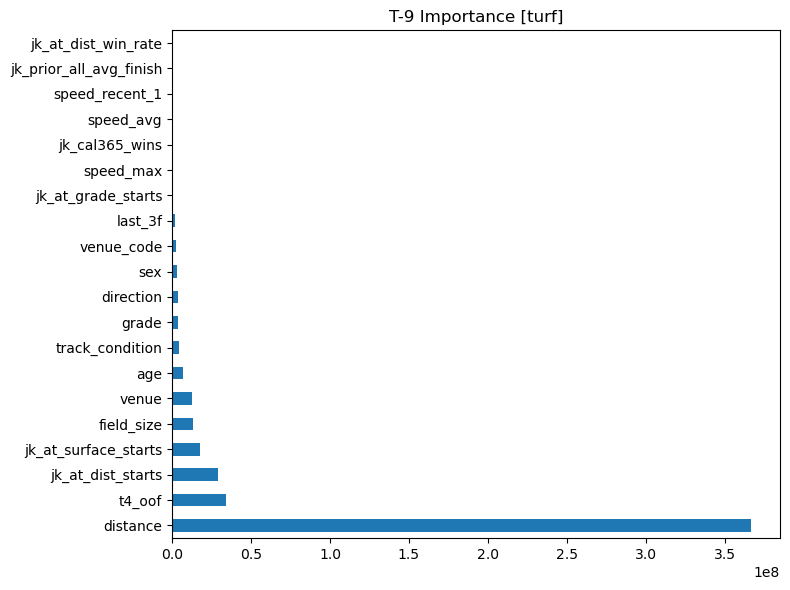

In [4]:
for sc, model in models_t9.items():
    df_te = df_clean[(df_clean["surface_cat"] == sc) & (df_clean["split"] == "test")]
    if df_te.empty: continue
    pred_te = model.predict(df_te[FEAT_T9])
    metrics = eval_regression(df_te["time_sec"].values, pred_te)
    sc_r, _ = spearmanr(df_te["time_sec"].dropna(), pred_te[:df_te["time_sec"].notna().sum()])
    print(f"[{sc}] Test: MAE={metrics['mae']:.3f}s  RMSE={metrics['rmse']:.3f}s  Spearman={sc_r:.4f}")

if not oof_all_t9.empty:
    oof_all_t9.to_parquet(OOF_DIR / "t9_oof.parquet", index=False)
    print(f"T-9 OOF saved: shape={oof_all_t9.shape}")

best_sc = max(models_t9, key=lambda s: models_t9[s].num_trees()) if models_t9 else None
if best_sc:
    imp = pd.Series(models_t9[best_sc].feature_importance(importance_type="gain"), index=FEAT_T9)
    imp.sort_values(ascending=False).head(20).plot.barh(figsize=(8,6), title=f"T-9 Importance [{best_sc}]")
    plt.tight_layout(); plt.show()
